In [2]:
import os, sys
import numpy as np
import torch
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sys.path.append('../')

from STARMap.utils import *
from STARMap.preprocess import *
from STARMap.STARMap_pyG import Train_STARMap

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

os.environ.setdefault('LANG', 'en_US.UTF-8')
os.environ.setdefault('LC_ALL', 'en_US.UTF-8')

r_home = detect_r_home()
mclust_ready = check_mclust(install_if_missing=False)
if mclust_ready:
    print('mclust OK')

R_HOME set to: D:/Anaconda/envs/spatialglue/lib/R
mclust OK


In [3]:
file_fold = '../Data/Mouse_Brain_E15.5/'
rna_file = file_fold + 'adata_RNA.h5ad'
atac_file = file_fold + 'adata_ATAC.h5ad'
scgpt_file = file_fold + 'scGPT_embedding.npy'
ground_truth_path = file_fold + 'GT_labels.txt'

adata_omics1 = sc.read_h5ad(rna_file)
adata_omics2 = sc.read_h5ad(atac_file)
adata_omics2 = align_adata_to_obs_names(adata_omics2, adata_omics1.obs_names)

scgpt_embedding = np.load(scgpt_file)
adata_omics3 = build_embedding_adata(
    scgpt_embedding,
    reference_adata=adata_omics1,
    var_prefix='scGPT',
    spatial_key='spatial',
)

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

data_type = 'Spatial-epigenome-transcriptome'
random_seed = 2022
fix_seed(random_seed)

In [4]:
n_top_hvg = 2000
n_top_svg = 0
svg_neighbors = 6
atac_min_cells = 10
atac_n_components = 21
feat_n_comps = 20

prep_results = prepare_starmap_brain_modalities(
    adata_omics1,
    adata_omics2,
    adata_omics3=adata_omics3,
    n_top_hvg=n_top_hvg,
    n_top_svg=n_top_svg,
    min_cells=10,
    spatial_key='spatial',
    svg_neighbors=svg_neighbors,
    atac_min_cells=atac_min_cells,
    atac_n_components=atac_n_components,
    feat_n_comps=feat_n_comps,
)
adata_omics1 = prep_results['adata_omics1']
adata_omics2 = prep_results['adata_omics2']
adata_omics3 = prep_results['adata_omics3']
selected_gene_mask = prep_results['selected_gene_mask']

HVG genes: 2000
SVG genes: 0
HVG | SVG genes: 2000


d:\Anaconda\envs\spatialglue\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [5]:
data = construct_neighbor_graph(adata_omics1, adata_omics2, adata_omics3, datatype=data_type)
model = Train_STARMap(
    data,
    datatype=data_type,
    device=device,
)
output = model.train()

e:\statistical modeling\model\Pipeline\..\STARMap\preprocess.py:607: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\bld\libtorch_1762156908853\work\torch\csrc\utils\tensor_new.cpp:655.)
  return torch.sparse.FloatTensor(indices, values, shape)
100%|██████████| 1600/1600 [07:07<00:00,  3.74it/s]

Model training finished!



In [6]:
adata = adata_omics1.copy()
attach_obsm_from_dict(
    adata,
    output,
    keys=[
        'emb_latent_omics1',
        'emb_latent_omics2',
        'emb_latent_omics3',
        'STARMap',
        'alpha',
        'alpha_omics1',
        'alpha_omics2',
        'alpha_omics3',
    ],
)

['emb_latent_omics1',
 'emb_latent_omics2',
 'emb_latent_omics3',
 'STARMap',
 'alpha',
 'alpha_omics1',
 'alpha_omics2',
 'alpha_omics3']

In [7]:
key = 'STARMap'
truth_key = 'ground_truth'
n_clusters = 10
method = 'mclust'

cluster_eval = run_embedding_clustering_evaluation(
    adata,
    embedding_key=key,
    label_path=ground_truth_path,
    n_clusters=n_clusters,
    method=method,
    truth_key=truth_key,
    pca_n_comps=30,
    random_seed=random_seed,
    pred_key=key,
)

scores_mclust = cluster_eval['scores']
labels_true = cluster_eval['labels_true']
label_order = cluster_eval['label_order']
confusion_mclust = cluster_eval['confusion']

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.
  


fitting ...
  |======================================================================| 100%


In [8]:
print(pd.Series(scores_mclust, name='mclust_global').round(4).to_string())

ARI                   0.4684
NMI                   0.5048
AMI                   0.4986
Homogeneity Score     0.5094
Completeness Score    0.5004
V-Measure             0.5048


d:\Anaconda\envs\spatialglue\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


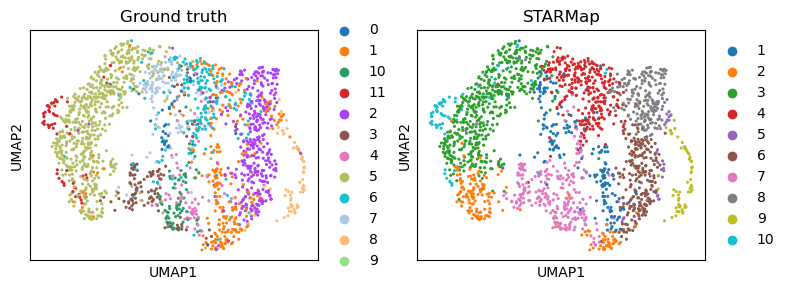

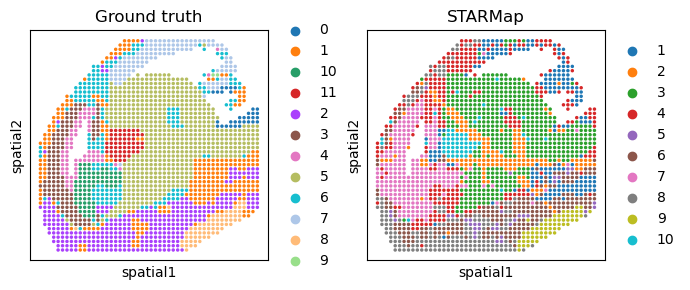

(<Figure size 700x300 with 2 Axes>,
 array([<Axes: title={'center': 'Ground truth'}, xlabel='spatial1', ylabel='spatial2'>,
        <Axes: title={'center': 'STARMap'}, xlabel='spatial1', ylabel='spatial2'>],
       dtype=object))

In [9]:
plot_umap_ground_truth_vs_prediction(
    adata,
    pred_key=key,
    truth_key='ground_truth',
    use_rep='STARMap',
    n_neighbors=10,
    figsize=(8, 3),
    point_size=20,
    pred_title='STARMap',
)

plot_spatial_cluster_comparison(
    adata,
    pred_key=key,
    truth_key='ground_truth',
    pred_title='STARMap',
)

fitting ...
  |======================================================================| 100%
Rare label 0: n=32, frac=1.64%, best_cluster=12, F1=0.414, MCC=0.417


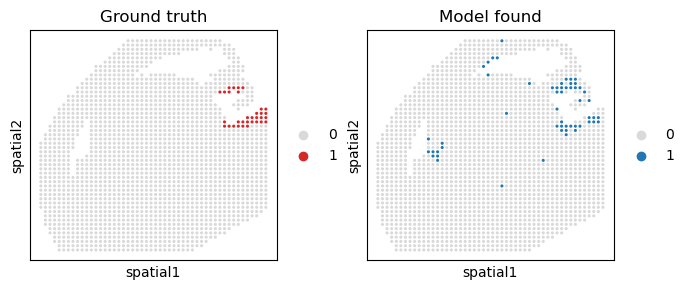

Rare label 11: n=55, frac=2.82%, best_cluster=19, F1=0.686, MCC=0.678


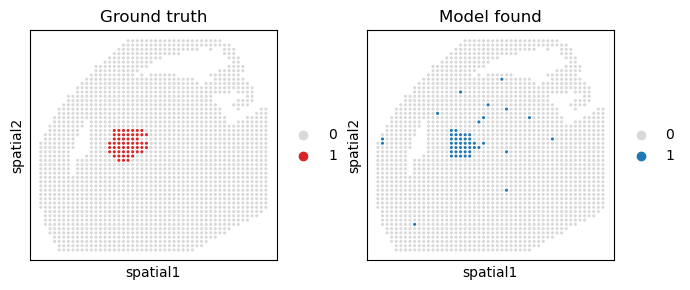

Rare label 8: n=66, frac=3.39%, best_cluster=6, F1=0.873, MCC=0.870


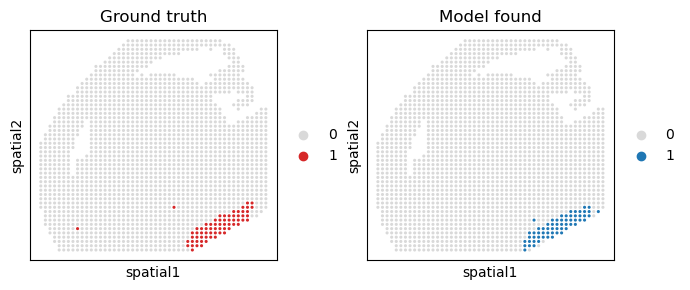

Rare label 4: n=69, frac=3.54%, best_cluster=11, F1=0.682, MCC=0.671


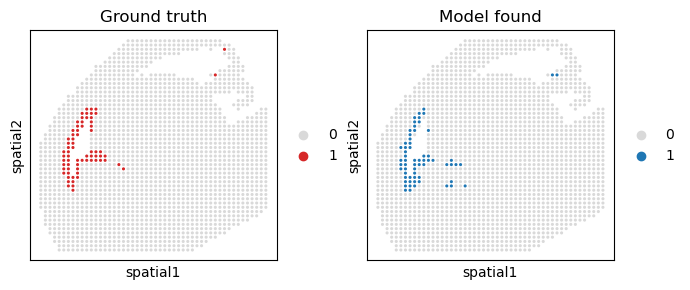

Rare label 10: n=75, frac=3.85%, best_cluster=1, F1=0.779, MCC=0.770


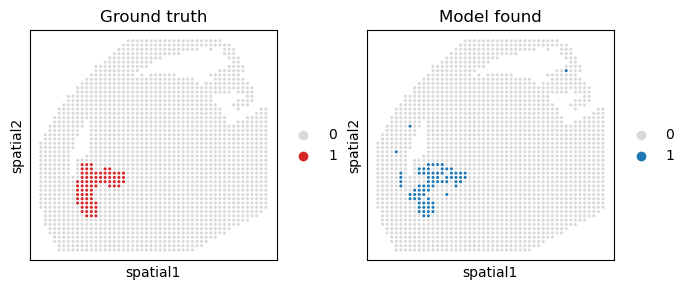

In [10]:
from STARMap.utils import summarize_best_matching_clusters, plot_rare_truth_vs_best_cluster_panels

rare_key = f"{key}_20"
_ = run_embedding_clustering_evaluation(
    adata,
    embedding_key=key,
    label_path=ground_truth_path,
    n_clusters=20,
    method=method,
    truth_key=truth_key,
    pca_n_comps=20,
    random_seed=random_seed,
    pred_key=rare_key,
)

_, rare_summary, _ = summarize_best_matching_clusters(
    adata,
    pred_key=rare_key,
    truth_key=truth_key,
    selection_metric="f1",
    exclude_truth_labels=['9'],
    rare_fraction_threshold=0.05
)

if not rare_summary.empty:
    _ = plot_rare_truth_vs_best_cluster_panels(
        adata, 
        rare_summary,
        label_key=truth_key, 
        pred_key=rare_key,
        basis='spatial',
        figsize=(7, 3),
        spatial_point_size=20
    )